In [2]:
from google.colab import files
uploaded=files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [3]:
import pandas as pd
df=pd.read_csv("IMDB Dataset.csv",encoding='latin-1')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.shape

(50000, 2)

In [6]:
df.isnull().sum()

,0
review,0
sentiment,0


<Axes: xlabel='sentiment', ylabel='count'>

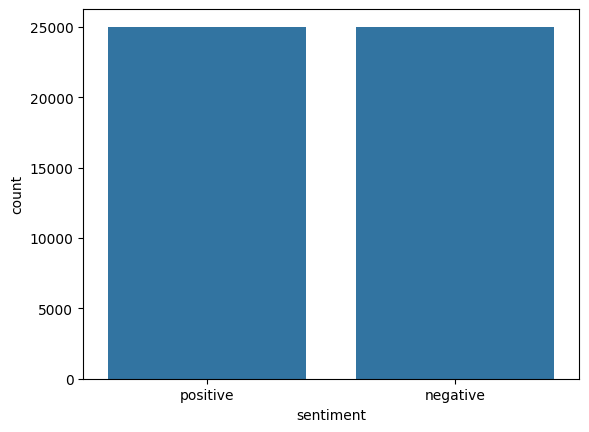

In [7]:
import seaborn as sns
sns.countplot(x="sentiment",data=df)

In [8]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [9]:
df["length"]=df["review"].str.len()
df.head()

,review,sentiment,length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [10]:
df["review"]=df["review"].str.lower()
df.head()

,review,sentiment,length
0,one of the other reviewers has mentioned that ...,positive,1761
1,a wonderful little production. <br /><br />the...,positive,998
2,i thought this was a wonderful way to spend ti...,positive,926
3,basically there's a family where a little boy ...,negative,748
4,"petter mattei's ""love in the time of money"" is...",positive,1317


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df["sentiment"]=encoder.fit_transform(df["sentiment"])
df.head()

,review,sentiment,length
0,one of the other reviewers has mentioned that ...,1,1761
1,a wonderful little production. <br /><br />the...,1,998
2,i thought this was a wonderful way to spend ti...,1,926
3,basically there's a family where a little boy ...,0,748
4,"petter mattei's ""love in the time of money"" is...",1,1317


In [12]:
import re

def preprocess_text(text):
    text=text.lower()
    text=re.sub(r'\S+@\S+\.\S+', 'emailaddress', text)
    text=re.sub(r'http\S+|www\S+', 'webaddress', text)
    text=re.sub(r'£|\$', 'dollers', text)
    text=re.sub(r'\(?\d{3}\)?[\s-]?\d{3}[\s-]?\d{4}', 'phonenumber', text)
    text=re.sub(r'\d+(\.\d+)?', 'numbr', text)
    text=re.sub(r'[^\w\s]', ' ', text)
    text=re.sub(r'\s+', ' ', text)
    return text.strip()

df['review']=df['review'].apply(preprocess_text)

In [13]:
df.head()

,review,sentiment,length
0,one of the other reviewers has mentioned that ...,1,1761
1,a wonderful little production br br the filmin...,1,998
2,i thought this was a wonderful way to spend ti...,1,926
3,basically there s a family where a little boy ...,0,748
4,petter mattei s love in the time of money is a...,1,1317


In [14]:
df["clean_length"]=df["review"].str.len()
df.head()

,review,sentiment,length,clean_length
0,one of the other reviewers has mentioned that ...,1,1761,1700
1,a wonderful little production br br the filmin...,1,998,958
2,i thought this was a wonderful way to spend ti...,1,926,896
3,basically there s a family where a little boy ...,0,748,716
4,petter mattei s love in the time of money is a...,1,1317,1267


<Axes: xlabel='length', ylabel='Count'>

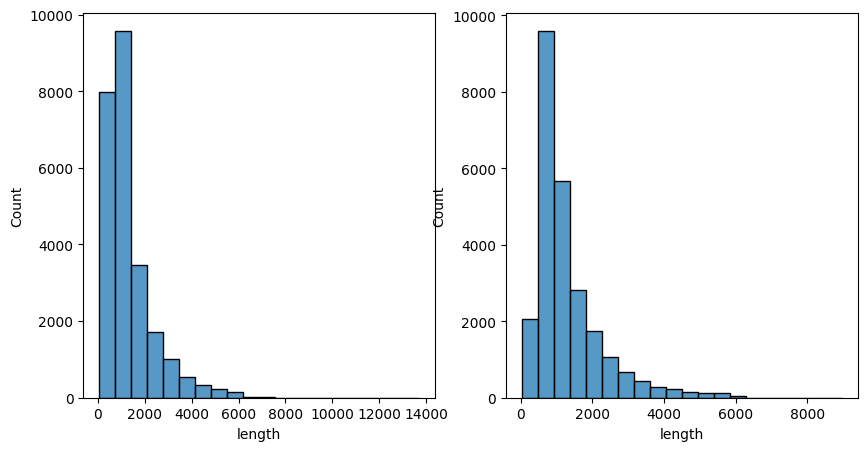

In [15]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.histplot(df[df['sentiment']==1]['length'],bins=20,ax=ax[0])
sns.histplot(df[df['sentiment']==0]['length'],bins=20,ax=ax[1])


<Axes: xlabel='clean_length', ylabel='Count'>

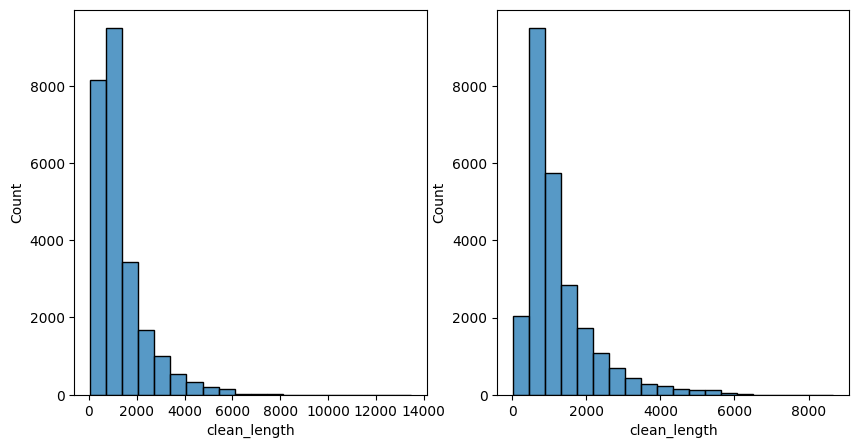

In [16]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.histplot(df[df['sentiment']==1]['clean_length'],bins=20,ax=ax[0])
sns.histplot(df[df['sentiment']==0]['clean_length'],bins=20,ax=ax[1])

In [17]:
from sklearn.model_selection import train_test_split

X=df['review']
y=df['sentiment']

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
bow=CountVectorizer()
X_train_bow=bow.fit_transform(X_train)
X_test_bow=bow.transform(X_test)

Model Training for Bow

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_bow, y_train)

y_pred_lr = lr.predict(X_test_bow)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

y_pred_nb = nb.predict(X_test_bow)

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train_bow, y_train)

y_pred_dt = dt.predict(X_test_bow)

Model Trainig for TF-IDF

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [23]:
# Logistic Regression (TF-IDF)
lr.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr.predict(X_test_tfidf)

# Naive Bayes (TF-IDF)
nb.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb.predict(X_test_tfidf)

# Decision Tree (TF-IDF)
dt.fit(X_train_tfidf, y_train)
y_pred_dt_tfidf = dt.predict(X_test_tfidf)

REPORT FOR BoW

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Logistic Regression (BoW)
print("LR BoW Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

# Naive Bayes (BoW)
print("NB BoW Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

# Decision Tree (BoW)
print("DT BoW Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

LR BoW Accuracy: 0.8883
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4367  594]
 [ 523 4516]]
NB BoW Accuracy: 0.8491
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      4961
           1       0.87      0.82      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

[[4360  601]
 [ 908 4131]]
DT BoW Accuracy: 0.7228
              precision    recall  f1-score   support

           0       0.72      0.73      0.72      4961
           1       0.73      0.72      0.72      5039

    accuracy                           0.72     10000
  

In [25]:
# Logistic Regression (TF-IDF)
print("LR TF-IDF Accuracy:", accuracy_score(y_test, y_pred_lr_tfidf))
print(classification_report(y_test, y_pred_lr_tfidf))
print(confusion_matrix(y_test, y_pred_lr_tfidf))

# Naive Bayes (TF-IDF)
print("NB TF-IDF Accuracy:", accuracy_score(y_test, y_pred_nb_tfidf))
print(classification_report(y_test, y_pred_nb_tfidf))
print(confusion_matrix(y_test, y_pred_nb_tfidf))

# Decision Tree (TF-IDF)
print("DT TF-IDF Accuracy:", accuracy_score(y_test, y_pred_dt_tfidf))
print(classification_report(y_test, y_pred_dt_tfidf))
print(confusion_matrix(y_test, y_pred_dt_tfidf))

LR TF-IDF Accuracy: 0.9012
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

[[4405  556]
 [ 432 4607]]
NB TF-IDF Accuracy: 0.8647
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      4961
           1       0.89      0.84      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000

[[4411  550]
 [ 803 4236]]
DT TF-IDF Accuracy: 0.7082
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      4961
           1       0.72      0.70      0.71      5039

    accuracy                           0.71    

Comparision

In [26]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Decision Tree'],
    'BoW Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ],
    'TF-IDF Accuracy': [
        accuracy_score(y_test, y_pred_lr_tfidf),
        accuracy_score(y_test, y_pred_nb_tfidf),
        accuracy_score(y_test, y_pred_dt_tfidf)
    ]
})

print(results)

                 Model  BoW Accuracy  TF-IDF Accuracy
0  Logistic Regression        0.8883           0.9012
1          Naive Bayes        0.8491           0.8647
2        Decision Tree        0.7228           0.7082


1. Preprocessing

Lowercasing and removing noise improved model performance
Removing special characters helped in better feature extraction

2. BoW vs TF-IDF

TF-IDF performed better than BoW because it gives less importance to frequent words

3. Best Model

Logistic Regression performed best among all models
It handled high-dimensional text data efficiently

4. Conclusion

TF-IDF + Logistic Regression is the best combination for this dataset